In [ ]:
# GGOR-tool analytisch

### Basis equation without ditch resistance

From the stationary equation for the symmetric X-section with half-width $b$, toplayer thickness $D$, horizontal conductivity $k_h$, recharge $N$, ditch water level $h_{LR}$, regional head $\phi$ and resistance $c$ against vertical flow between the top layer and the regional aquifer and $\lambda=\sqrt{kDc}$:

$$
h-\left(\phi+Nc\right)=\left(h_{LR}-\left(\phi+Nc\right)\right)\frac{\cosh\frac{x}{\lambda}}{\cosh\frac{b}{\lambda}}
$$

The derived dynamic version with given upward seepage $q$ [L/T] is

$$
\overline{h}-h_{LR}=\left(\overline{h}_{t_{0}}-h_{LR}\right)\exp\left(-\frac{t-t_{0}}{T}\right)+\left(N+q\right)c\Gamma\left[1-\exp\left(-\frac{t-t_{0}}{T}\right)\right]
$$

| Symbol | Unit | Description |
|-------:|:----:|-------------|
| $t$ | [T] | Time |
| $t_0$ | [T] | Start of time step |
| $N$ | [L/T] | Recharge from rain minus evapotranspiration |
| $q$ | [L/T] | Upward seepage |
| $\overline{h}$ | [L] | Water table elevation, averaged over the cross section |
| $h_{LR}$ | [L] | Ditch water level at left and right of the cross section |
| $T$ | [T] | Characteristic time of the groundwater system in the cross section |


with

$$
T=\mu c\frac{b}{\lambda}\coth\left(\frac{b}{\lambda}\right)
$$

with

| Symbol | Unit | Description |
|-------:|:----:|-------------|
| $\mu$ | [-] | Specific yield | 
| $c$   | [T] | Vertical resistance betwee top layer and underlying regional aquifer |
| $b$   | [L] | Half-width of the X-section |
| $\lambda=\sqrt{k_h D}$ | [L] | Characteristic length of the shallow grondwater system |
| $k_h$ | [L/T] | Average horizontal conductivity of the top layer |
| $D$   | [L]   | thickness of the top layer |

and

$$
\Gamma=\frac{b}{\lambda}\coth\left(\frac{b}{\lambda}\right)-1
$$

with parameters given above.




In [161]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from itertools import cycle


In [ ]:
class Meteo():
    """Class to handle meteo data."""
    
    def __init__(self, met_csv_file):
        """Get the meteo time series data from csv file."""
        
        assert os.path.isfile(met_csv_file), f"No such file {met_csv_file}"
        
        met = pd.read_csv(met_csv_file, skiprows=16, header=None)
        
        met.columns = ['STN','YYYYMMDD',   'DR',   'RH',  'RHX', 'RHXH', 'EV24']
        
        met.index = [__class__.to_timestamp(p) for p in met['YYYYMMDD']]
        
        met = met[['RH', 'EV24']]
        
        met['RH'] = __class__.met_col_to_m(met['RH'])
        met['EV24'] = __class__.met_col_to_m(met['EV24'])
        
        self.data = met
    
    @staticmethod
    def to_timestamp(p):
        """Return timestamp from int like 20251218.
        
        to_timestamp(20251218) --> pd.Timestap("2025-12-18")
        """
        p = str(p)
        return pd.Timestamp(f"{p[:4]}-{p[4:6]}-{p[6:8]}")

    @staticmethod
    def met_col_to_m(metcol):
        """Conver meteo column data from 10ths of mm to m"""
        values = metcol.values / 10000
        values[values < 0] = 0.00005
        return values


def title_fr_data_dict(data_dict):
    title_items = []
    for k, v in data_dict.items():
        title_items.append(f"{k}={v}")
    return ', '.join(title_items)


In [ ]:
P = Path(os.getcwd())
home = os.path.join(*P.parts[:P.parts.index('AAN_GZK') + 1])
meteo = os.path.join(home, 'meteo')

assert os.path.isdir(meteo), 'Meteo dir not found.'

meteo_file = os.path.join(meteo, os.listdir(meteo)[0])

met=get_meteo(meteo_file)
met.mean()

RH      0.002252
EV24    0.001693
dtype: float64

In [ ]:
class Analytic():

    def __init__(self, b, D, k, c, mu):
        """Instantiate analytic simulator.
        
        Parameters
        ----------
        b: float [L]
            half-wdith of the X-section
        D: float [L]
            top layer thickness.
        k: float [L/t]
            hydraulic hoirzontal conductivity
        c: float [T]    
            vertical resistance between top layer and regional aquifer
        mu: float [-]
            specific yield of the top layer
        q: float [L/T]
            upward seepage from regional aquifer (downward is negative)
        """        
        self.k, self.b, self.D, self.c, self.mu = k, b, D, c, mu
     
    
    @property
    def lam(self):
        """Return spreading length of the top groundwater system.
        
        lambda = sqrt(kDc)
        
        """
        return np.sqrt(self.k * self.D * self.c)    

    @property
    def T(self):
        """Return characteristic time of top groundwater system.
        
        T = mu c (b / lambda) * coth(b / lambda)
        
        """
        L = self.lam
        return self.mu * self.c * self.b / L * Analytic.coth(self.b / L)
    
    @property
    def G(self):
        """Return factor popping up in the steady case derivation.
        
        G = b / Lambda * coth( b / lambda) - 1
        
        """
        L = self.lam
        return self.b / L * Analytic.coth(self.b / L) - 1
    
    @classmethod
    def coth(cls, x):
        """Return coth (not in numpy or scipy)"""
        return 1 / np.tanh(x)
        
    def steady(self, Nx=None, phi=None, hLR=None, N=None, **kwargs):
        """Return steady state solution of cross section x.
        
        Nx: float [m] 
            steps in half X section
        phi: float [L]
            uniform head in regional aquifer
        hLR: float [L]
            water level in the ditch
        N: float [L/T]
            recharge rate
        """
        x = np.linspace(-self.b, self.b, Nx + 1)        
        h = (phi + N * self.c) + (hLR - (phi + N * self.c)) * np.cosh(x/self.lam) / np.cosh(self.b/self.lam)
        return h, x
    
    def steady_avg(self, phi=None, hLR=None, N=None, **kwargs):
        """Return the averages steady-state head."""
        return (phi + N * self.c) + (hLR - (phi + N * self.c)) * np.tanh(self.b/self.lam) / (self.b/self.lam)

    def transient(self, tdata, h_summer=None, h_winter=None, q=None, t0=pd.Timestamp('2010-01-01')):
        """Return result of dynamic simulation.

        Parameters
        ----------
        tdata: pd.DataFrame
            Meteo data (columns RH and EV24)
        h_summer, h_winter: floats
            summer and winter ditch levels
        q: float or series:
            upward seepage rate
        """
        # --- prepare the tdata DataFrame
        
        # --- use only data for t>t0
        tdata = tdata.loc[tdata.index >= t0]
        
        # --- add column with recharge N               
        tdata['N'] = tdata['RH'] - tdata['EV24']
        
        # --- add boolean column to see when it's summer or winter
        tdata['summer'] = np.logical_and(tdata.index.month >= 4, tdata.index.month <= 9)
        
        # --- add column with ditch water level according to summer or winter
        tdata['hLR'] = h_winter
        tdata.loc[tdata['summer'], 'hLR'] = h_summer
        
        # --- add column with upward seepage
        tdata['q'] = q
                
        # --- initialize the column with the computed heads
        tdata['havg'] = h_summer
        
        # --- which column of the DataFrame corresponds with the computed heads?
        icol = list(tdata.columns).index('havg')
        
        # --- end of ghe previous day
        t0 = tdata.index[0] - np.timedelta64(1, 'D')
        
        # --- Head at the start of the first day
        h0 = tdata['hLR'].loc[tdata.index[0]] 
        
        for it,(t, N, hLR, q) in enumerate(tdata[['N', 'hLR', 'q']].itertuples()):

            # --- allow timesteps to vary
            dt = (t - t0) / np.timedelta64(1, 'D')
            
            exp = np.exp(-dt / self.T)
            havg =hLR +  (h0 - hLR) * exp +  (N + q) * self.c * self.G * (1 - exp)
            
            # --- havg is for the start of the next day, because it used the data of today.
            try:
                tdata.iloc[it + 1, icol] = havg
            except Exception:
                print(f"Done, it={it}")
                break
            h0 = havg
            t0 = t
            
        tdata['phi'] = havg + tdata['q'] * self.c
        return tdata
    
    def transient_t_to_infty(self, N=None, q=None, hLR=None, **kwargs):
        """Return the transient solution for t at infinity (sready X-section average)
        
        havg = hLR + (N + q) c G
        
        """
        print(hLR, N, q, self.c, self.G)
        return hLR + (N + q) * self.c * self.G

### Steady state simulation and compare with analyic single layer solution

First compute the steady-state solution and compare with the analytic solution for a single layer with no leakage (fixed $kD$)

The two lines should fall on top of eachother when the resistance is high.

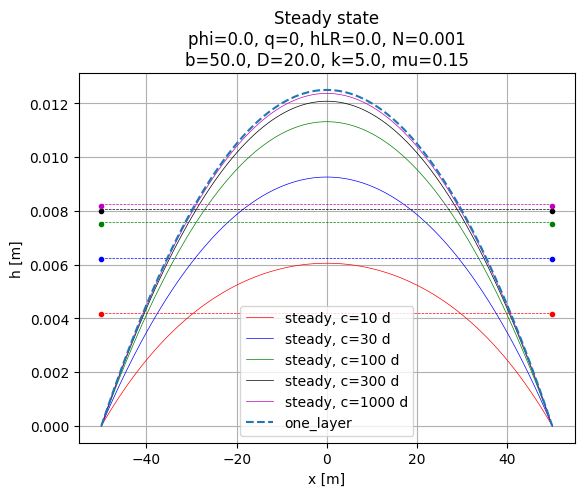

In [187]:
# --- The aquifer data
data = dict(b=50., D=20., k=5., mu=0.15)

# --- We'll use it in the figure title
title2 = title_fr_data_dict(data)

# --- Specific data for the steady case
data_steady = dict(phi=0., q=0, hLR=0., N=0.001)

# --- We'll add this to the title as well
title3 = title_fr_data_dict(data_steady)

# --- Show the results for a set of c-values
fig, ax = plt.subplots()
ax.set_title("Steady state" + "\n" + title3 + "\n" + title2)
ax.set(xlabel='x [m]', ylabel="h [m]")

clrs = cycle('rbgkmc')
for c in [10, 30, 100, 300, 1000]:
    clr = next(clrs)
    
    # --- Compute the steady head
    model = Analytic(c=c, **data)
    hx, x = model.steady(Nx=100, **data_steady)
    
    havg = model.steady_avg(**data_steady)

    ax.plot(x, hx, color=clr, label=f"steady, c={c} d", lw=0.5)
    ax.plot(x[[0, -1]], [havg, havg], '--', color=clr, lw=0.5)
    ax.plot(x[[0, -1]], [hx.mean(), hx.mean()], '.', color=clr, lw=0.5)

# --- Add analytic solution for a single layer groundwater system with fixed kD
h = data_steady['N'] * np.abs(model.b**2 - x**2) / (2 * model.k * model.D)
ax.plot(x, h, '--', label='one_layer')

ax.grid(True)
ax.legend()

### Transient simulation

Done, it=3651
Done, it=3651


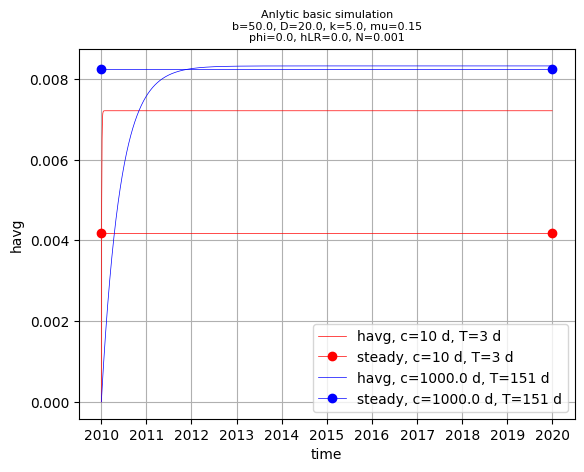

In [208]:
data = dict(b=50., D=20., k=5., mu=0.15)
data_steady = dict(phi=0., hLR=0., N=0.001)


# --- We'll use it in the figure title
title2 = title_fr_data_dict(data)
title3 = title_fr_data_dict(data_steady)

# --- Seasonal fluctuation of ditch level
h_summer, h_winter = 0., 0.

ttest = met.copy()

# --- Uniform test data overwrites meteo-data
ttest['RH'] = 0.001
ttest['EV24'] = 0.
ttest['q'] = 0.

fig, ax = plt.subplots()

title = 'Anlytic basic simulation' + '\n' + title2 + "\n" + title3

ax.set_title(title, fontsize=8)
ax.set(xlabel='time', ylabel='havg')

clrs = cycle('rbgkmc')
for c in [10, 1000.]: # 30, 100, 300, 1000]:
    clr = next(clrs)
    data['c'] = c
    model = Analytic(**data)

    # ---Use tdata for the simulation and return the version updated with the results.
    tdata = model.transient(tdata=ttest.copy(), h_winter=-h_winter, h_summer=h_summer, q=0., t0=pd.Timestamp('2010-01-01'))

    ax.plot(tdata.index, tdata['havg'], color=clr, lw=0.5, label=f"havg, c={model.c} d, T={model.T:.0f} d")    
    
    # --- Compare steady state result.
    havg = model.steady_avg(**data_steady)
    ax.plot(met.index[[0, -1]], [havg, havg], 'o-', color=clr, lw=0.5, label=f"steady, c={model.c} d, T={model.T:.0f} d")


ax.grid(True)
ax.legend()


### Transient simulation with varying data

Done, it=3651
Done, it=3651


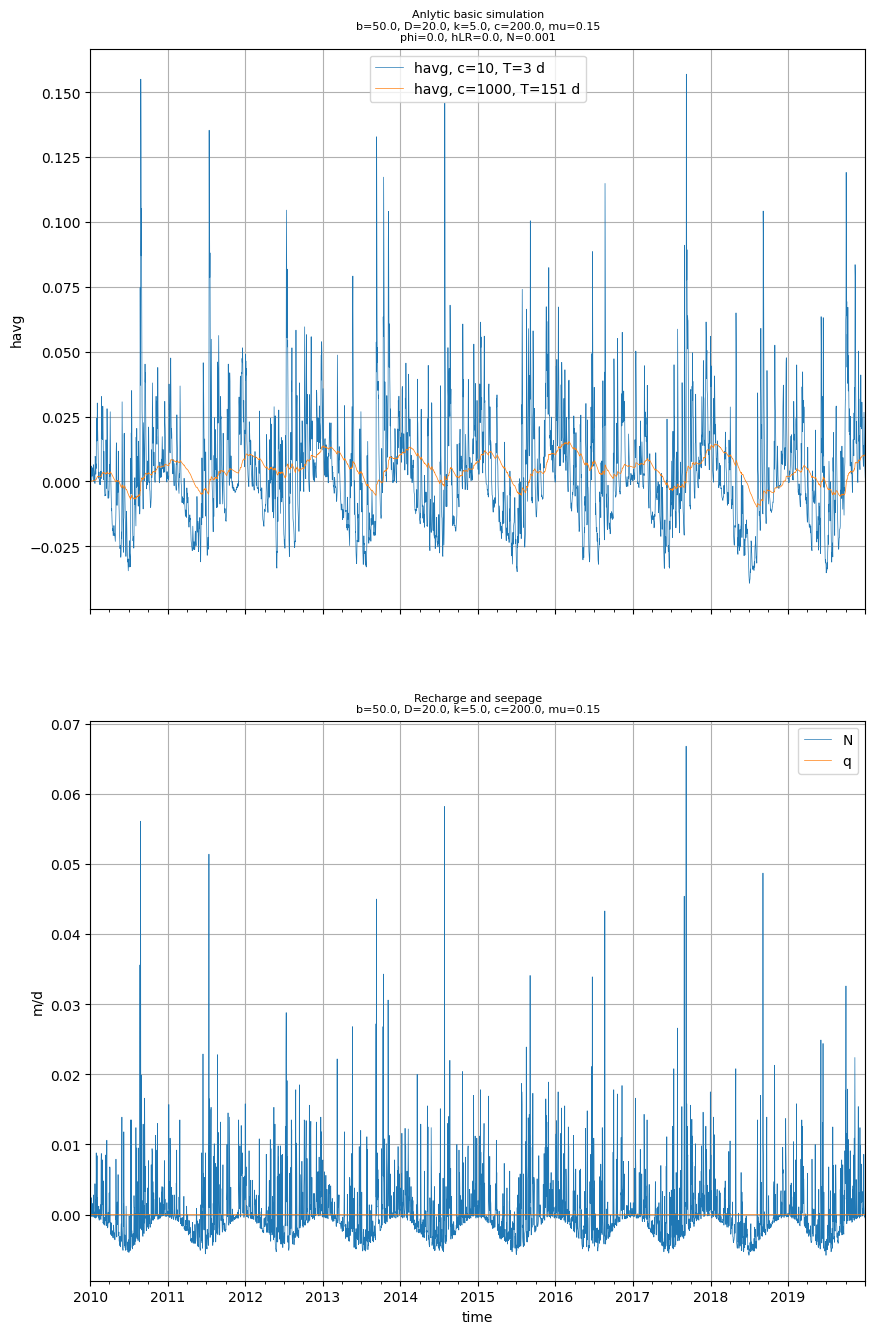

In [207]:
data = dict(b=50., D=20., k=5., c=200., mu=0.15)

# --- We'll use it in the figure title
title2 = title_fr_data_dict(data)

# --- Seasonal fluctuation of ditch level
h_summer, h_winter = 0., 0.

ttest = met.copy()

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 16))

title = 'Anlytic basic simulation' + '\n' + title2 + "\n" + title3

axs[0].set_title(title, fontsize=8)
axs[0].set(xlabel='time', ylabel='havg')

clrs = cycle('rbgkmc')
for c in [10, 1000]: # 30, 100, 300, 1000]:
    clr = next(clrs)
    data['c'] = c
    model = Analytic(**data)

    # ---Use tdata for the simulation and return the version updated with the results.
    tdata = model.transient(tdata=met.copy(), h_winter=-h_winter, h_summer=h_summer, q=0., t0=pd.Timestamp('2010-01-01'))

    axs[0].plot(tdata.index, tdata['havg'], lw=0.5, label=f"havg, c={model.c}, T={model.T:.0f} d")        

axs[0].grid(True)
axs[0].legend()

title = 'Recharge and seepage' + '\n' + title2
axs[1].set_title(title, fontsize=8)

axs[1].set(xlabel='time', ylabel='m/d')
tdata['N'].plot(ax=axs[1], label='N', lw=0.5)
tdata['q'].plot(ax=axs[1], label='q', lw=0.5)
axs[1].grid(True)
axs[1].legend()
